In [ ]:
import pandas as pd
df = pd.read_csv("../data/train.csv") 
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
y = df["Time_taken(min)"]

In [9]:
df = df.drop(columns=["ID", "Delivery_person_ID"], errors="ignore")

In [10]:
for col in df.columns:
    print(col)

Delivery_person_Age
Delivery_person_Ratings
Restaurant_latitude
Restaurant_longitude
Delivery_location_latitude
Delivery_location_longitude
Order_Date
Time_Orderd
Time_Order_picked
Weatherconditions
Road_traffic_density
Vehicle_condition
Type_of_order
Type_of_vehicle
multiple_deliveries
Festival
City
Time_taken(min)


In [11]:
df.columns = df.columns.str.strip()
y = df["Time_taken(min)"]

In [15]:
df["Time_Orderd"] = df["Time_Orderd"].astype(str)
df["Time_Order_picked"] = df["Time_Order_picked"].astype(str)

df["order_hour"] = df["Time_Orderd"].str.split(":").str[0]
df["pickup_hour"] = df["Time_Order_picked"].str.split(":").str[0]

df["order_hour"] = pd.to_numeric(df["order_hour"], errors="coerce")
df["pickup_hour"] = pd.to_numeric(df["pickup_hour"], errors="coerce")

df["order_hour"].fillna(df["order_hour"].median(), inplace=True)
df["pickup_hour"].fillna(df["pickup_hour"].median(), inplace=True)

df["prep_time"] = df["pickup_hour"] - df["order_hour"]

C:\Users\ankit\AppData\Local\Temp\ipykernel_21696\1931685425.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["order_hour"].fillna(df["order_hour"].median(), inplace=True)
C:\Users\ankit\AppData\Local\Temp\ipykernel_21696\1931685425.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

In [16]:
df[["Time_Orderd", "order_hour"]].head()

,Time_Orderd,order_hour
0,11:30:00,11.0
1,19:45:00,19.0
2,08:30:00,8.0
3,18:00:00,18.0
4,13:30:00,13.0


In [17]:
from geopy.distance import geodesic

def calc_distance(row):
    return geodesic(
        (row["Restaurant_latitude"], row["Restaurant_longitude"]),
        (row["Delivery_location_latitude"], row["Delivery_location_longitude"]),
    ).kilometers
df["distance_km"] = df.apply(calc_distance, axis=1)

In [18]:
df[["distance_km"]].head()

,distance_km
0,3.020737
1,20.143737
2,1.549693
3,7.774497
4,6.197898


In [19]:
df = df.drop(columns=[
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked"
])

In [20]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_hour,pickup_hour,prep_time,distance_km
0,37,4.9,22.745049,75.892471,22.765049,75.912471,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24,11.0,11,0.0,3.020737
1,34,4.5,12.913041,77.683237,13.043041,77.813237,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33,19.0,19,0.0,20.143737
2,23,4.4,12.914264,77.678400,12.924264,77.688400,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26,8.0,8,0.0,1.549693
3,38,4.7,11.003669,76.976494,11.053669,77.026494,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21,18.0,18,0.0,7.774497
4,32,4.6,12.972793,80.249982,13.012793,80.289982,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30,13.0,13,0.0,6.197898


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          45593 non-null  str    
 1   Delivery_person_Ratings      45593 non-null  str    
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Weatherconditions            45593 non-null  str    
 7   Road_traffic_density         45593 non-null  str    
 8   Vehicle_condition            45593 non-null  int64  
 9   Type_of_order                45593 non-null  str    
 10  Type_of_vehicle              45593 non-null  str    
 11  multiple_deliveries          45593 non-null  str    
 12  Festival                     45593 non-null  str    
 13  City                       

In [22]:
# convert to numeric

df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")

# target fix
df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min)", "")
df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors="coerce")

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.info()

In [25]:
df = pd.get_dummies(df, columns=[
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
], drop_first=True)

In [26]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min),order_hour,...,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_No,Festival_Yes,City_NaN,City_Semi-Urban,City_Urban
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2,0.0,24,11.0,...,False,True,False,True,False,True,False,False,False,True
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2,1.0,33,19.0,...,False,True,False,False,True,True,False,False,False,False
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,0,1.0,26,8.0,...,False,False,False,True,False,True,False,False,False,True
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,0,1.0,21,18.0,...,False,False,False,True,False,True,False,False,False,False
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,1,1.0,30,13.0,...,False,True,False,False,True,True,False,False,False,False


In [27]:
X = df.drop(columns=["Time_taken(min)"])
y = df["Time_taken(min)"]

In [28]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(n_estimators=100)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [29]:
from sklearn.metrics import mean_absolute_error
pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

MAE: 3.229203462600708


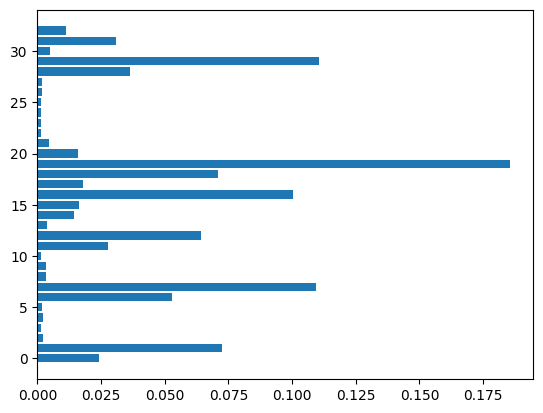

In [30]:
import matplotlib.pyplot as plt
importances = model.feature_importances_
plt.barh(range(len(importances)), importances)
plt.show()

c:\Users\ankit\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


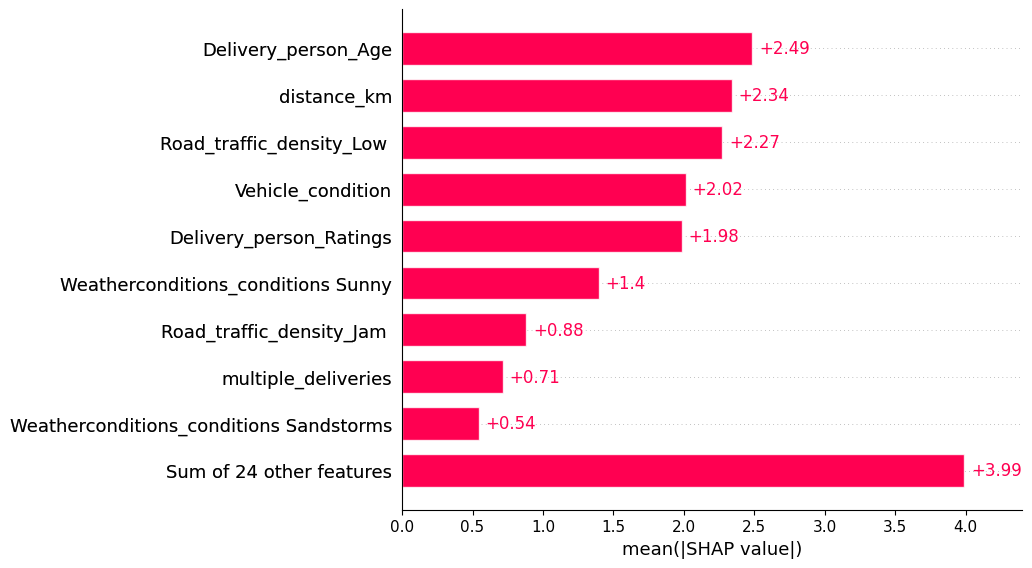

In [31]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Vehicle_condition",
    "multiple_deliveries",
    "order_hour",
    "pickup_hour",
    "prep_time",
    "distance_km"
]

X = df[features]
y = df["Time_taken(min)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(n_estimators=100)
model.fit(X_train, y_train)

In [3]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

In [4]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [5]:
# column clean
df.columns = df.columns.str.strip()
# numeric conversion
df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")

# target clean
df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min)", "")
df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors="coerce")

# missing fill
df.fillna(df.median(numeric_only=True), inplace=True)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45589,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45590,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45591,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [7]:
# time features
df["order_hour"] = pd.to_numeric(df["Time_Orderd"].str.split(":").str[0], errors="coerce")
df["pickup_hour"] = pd.to_numeric(df["Time_Order_picked"].str.split(":").str[0], errors="coerce")

df["order_hour"].fillna(df["order_hour"].median(), inplace=True)
df["pickup_hour"].fillna(df["pickup_hour"].median(), inplace=True)

df["prep_time"] = df["pickup_hour"] - df["order_hour"]

C:\Users\ankit\AppData\Local\Temp\ipykernel_16024\2982611198.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["order_hour"].fillna(df["order_hour"].median(), inplace=True)
C:\Users\ankit\AppData\Local\Temp\ipykernel_16024\2982611198.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

In [8]:
df[["order_hour", "pickup_hour", "prep_time"]].head()

,order_hour,pickup_hour,prep_time
0,11.0,11,0.0
1,19.0,19,0.0
2,8.0,8,0.0
3,18.0,18,0.0
4,13.0,13,0.0


In [9]:
df.to_csv("../data/cleaned_data.csv", index=False)

In [10]:
df = pd.read_csv("../data/cleaned_data.csv")

In [11]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_hour,pickup_hour,prep_time
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,2,Snack,motorcycle,0.0,No,Urban,24,11.0,11,0.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,2,Snack,scooter,1.0,No,Metropolitian,33,19.0,19,0.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,0,Drinks,motorcycle,1.0,No,Urban,26,8.0,8,0.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,0,Buffet,motorcycle,1.0,No,Metropolitian,21,18.0,18,0.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,1,Snack,scooter,1.0,No,Metropolitian,30,13.0,13,0.0


In [12]:
features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Vehicle_condition",
    "multiple_deliveries",
    "order_hour",
    "pickup_hour",
    "prep_time"
]

X = df[features]
y = df["Time_taken(min)"]

In [13]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(n_estimators=100)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [14]:
import pickle

pickle.dump(model, open("../model/model.pkl", "wb"))

c:\Users\ankit\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


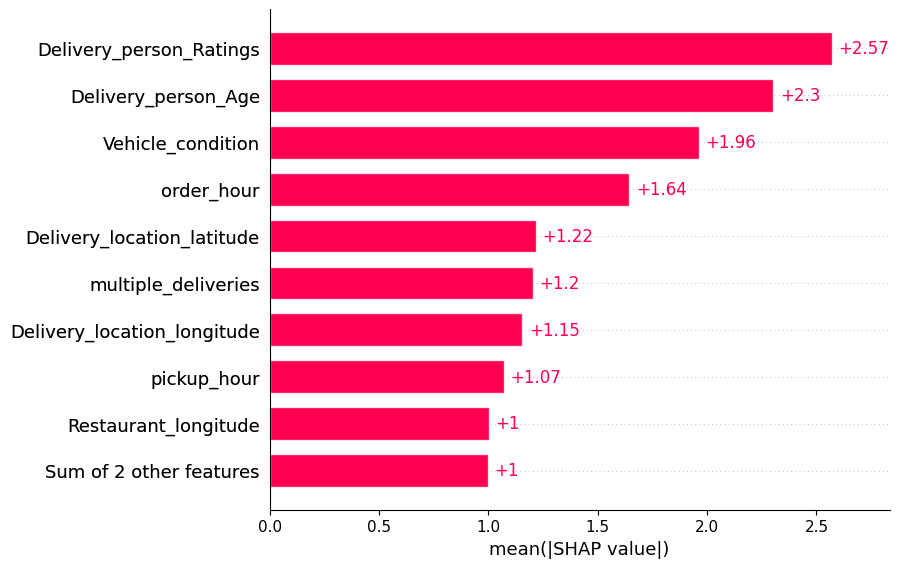

In [15]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)